# End-To-End Memory Networks (MemN2N)

This notebook implements the **End-To-End Memory Networks** architecture proposed by Sukhbaatar et al. (2015). We cover two tasks:

1. **Synthetic Question Answering** on the bAbI dataset

The key idea is a recurrent attention mechanism over an external memory, trained fully end-to-end via backpropagation unlike the original Memory Networks which required supervision at each layer.

---

## 1. Setup and Dependencies

In [8]:
import os
import math
import urllib
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import tarfile

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def _get_device():
    if not torch.cuda.is_available():
        return torch.device('cpu')
    try:
        torch.zeros(1).cuda()
        return torch.device('cuda')
    except Exception:
        return torch.device('cpu')

DEVICE = _get_device()
print(f'Using device: {DEVICE}')

Using device: cuda


---
## Data Loading bAbI

The bAbI dataset consists of 20 synthetic QA tasks, each designed to test a specific type of reasoning (e.g., path finding, coreference, counting). Each sample is a list of sentences (the story), a question, and a single-word answer.

In [9]:
# Download bAbI dataset if not already present
BABI_URL = 'https://s3.amazonaws.com/text-datasets/babi_tasks_1-20_v1-2.tar.gz'
BASE_DIR = '/kaggle/working' if os.path.exists('/kaggle/working') else '../'
BABI_DIR = os.path.join(BASE_DIR, 'babi_data')


is_data_downloaded = os.path.exists(os.path.join(BABI_DIR, 'tasks_1-20_v1-2', 'en-10k'))
if not is_data_downloaded:
    print('Downloading bAbI dataset...')
    os.makedirs(BABI_DIR, exist_ok=True)
    tar_path = os.path.join(BASE_DIR, 'babi.tar.gz')
    urllib.request.urlretrieve(BABI_URL, tar_path)
    with tarfile.open(tar_path) as f:
        f.extractall(BABI_DIR)
    os.remove(tar_path)
    print('Done.')
else:
    print('bAbI data already downloaded.')

bAbI data already downloaded.


---
## 2. Dataset Analysis

Before building anything, it's worth spending a few minutes actually looking at the data. The bAbI dataset has 20 tasks — each one tests a different kind of reasoning. Here we'll get a feel for the scale, structure, and what the model is actually being asked to do.

In [10]:
data_dir = os.path.join(BABI_DIR, 'tasks_1-20_v1-2', 'en-10k')

TASK_NAMES = {
    1: 'single-supporting-fact', 2: 'two-supporting-facts',
    3: 'three-supporting-facts', 4: 'two-arg-relations',
    5: 'three-arg-relations',    6: 'yes-no-questions',
    7: 'counting',               8: 'lists-sets',
    9: 'simple-negation',        10: 'indefinite-knowledge',
    11: 'basic-coreference',     12: 'conjunction',
    13: 'compound-coreference',  14: 'time-reasoning',
    15: 'basic-deduction',       16: 'basic-induction',
    17: 'positional-reasoning',  18: 'size-reasoning',
    19: 'path-finding',          20: 'agents-motivations'
}

def parse_task(path):
    stories, story_lens, answers = 0, [], []
    cur_len = 0
    with open(path) as f:
        for line in f:
            idx = int(line.strip().split(' ', 1)[0])
            if idx == 1 and cur_len > 0:
                story_lens.append(cur_len); cur_len = 0; stories += 1
            cur_len += 1
            if '\t' in line:
                answers.append(line.strip().split('\t')[1].strip().lower())
    if cur_len: story_lens.append(cur_len); stories += 1
    return stories, story_lens, answers

stats = {}
for tid in range(1, 21):
    tr = [f for f in os.listdir(data_dir) if f.startswith('qa%d_' % tid) and 'train' in f][0]
    te = [f for f in os.listdir(data_dir) if f.startswith('qa%d_' % tid) and 'test'  in f][0]
    tr_s, tr_lens, tr_ans = parse_task(os.path.join(data_dir, tr))
    te_s, te_lens, te_ans = parse_task(os.path.join(data_dir, te))
    stats[tid] = dict(
        name=TASK_NAMES[tid], tr_stories=tr_s, te_stories=te_s,
        tr_qa=len(tr_ans), avg_story_len=round(sum(tr_lens)/len(tr_lens), 1),
        unique_ans=len(set(tr_ans + te_ans)), answers=tr_ans + te_ans
    )

total_train_qa = sum(s['tr_qa'] for s in stats.values())
total_words = sum(
    len(line.split()) for fname in os.listdir(data_dir)
    if fname.endswith('.txt')
    for line in open(os.path.join(data_dir, fname))
)

print("=== bAbI Dataset — Quick Overview ===\n")
print(f"20 tasks, each testing a different reasoning skill")
print(f"{total_train_qa:,} training QA pairs in total (10k per task)")
print(f"~{total_words:,} total word tokens across all files")
print(f"Vocabulary: only ~145 unique words — intentionally tiny")
print()

# Hardest tasks by average story length
sorted_by_len = sorted(stats.items(), key=lambda x: x[1]['avg_story_len'], reverse=True)
print("Tasks with the longest stories (most context to remember):")
for tid, s in sorted_by_len[:5]:
    print(f"Task {tid:>2} ({s['name']:<28}) avg {s['avg_story_len']:>5} lines/story")

print()
print("Tasks with the smallest answer space (almost binary):")
for tid, s in stats.items():
    if s['unique_ans'] <= 2:
        print(f"Task {tid:>2} ({s['name']:<28}) only {s['unique_ans']} possible answers")


=== bAbI Dataset — Quick Overview ===

20 tasks, each testing a different reasoning skill
200,000 training QA pairs in total (10k per task)
~6,658,468 total word tokens across all files
Vocabulary: only ~145 unique words — intentionally tiny

Tasks with the longest stories (most context to remember):
Task  3 (three-supporting-facts      ) avg  79.4 lines/story
Task  5 (three-arg-relations         ) avg  32.3 lines/story
Task  2 (two-supporting-facts        ) avg  27.0 lines/story
Task 20 (agents-motivations          ) avg  21.4 lines/story
Task  8 (lists-sets                  ) avg  18.3 lines/story

Tasks with the smallest answer space (almost binary):
Task  6 (yes-no-questions            ) only 2 possible answers
Task  9 (simple-negation             ) only 2 possible answers
Task 17 (positional-reasoning        ) only 2 possible answers
Task 18 (size-reasoning              ) only 2 possible answers


FileNotFoundError: [Errno 2] No such file or directory: '../images/babi_analysis.png'

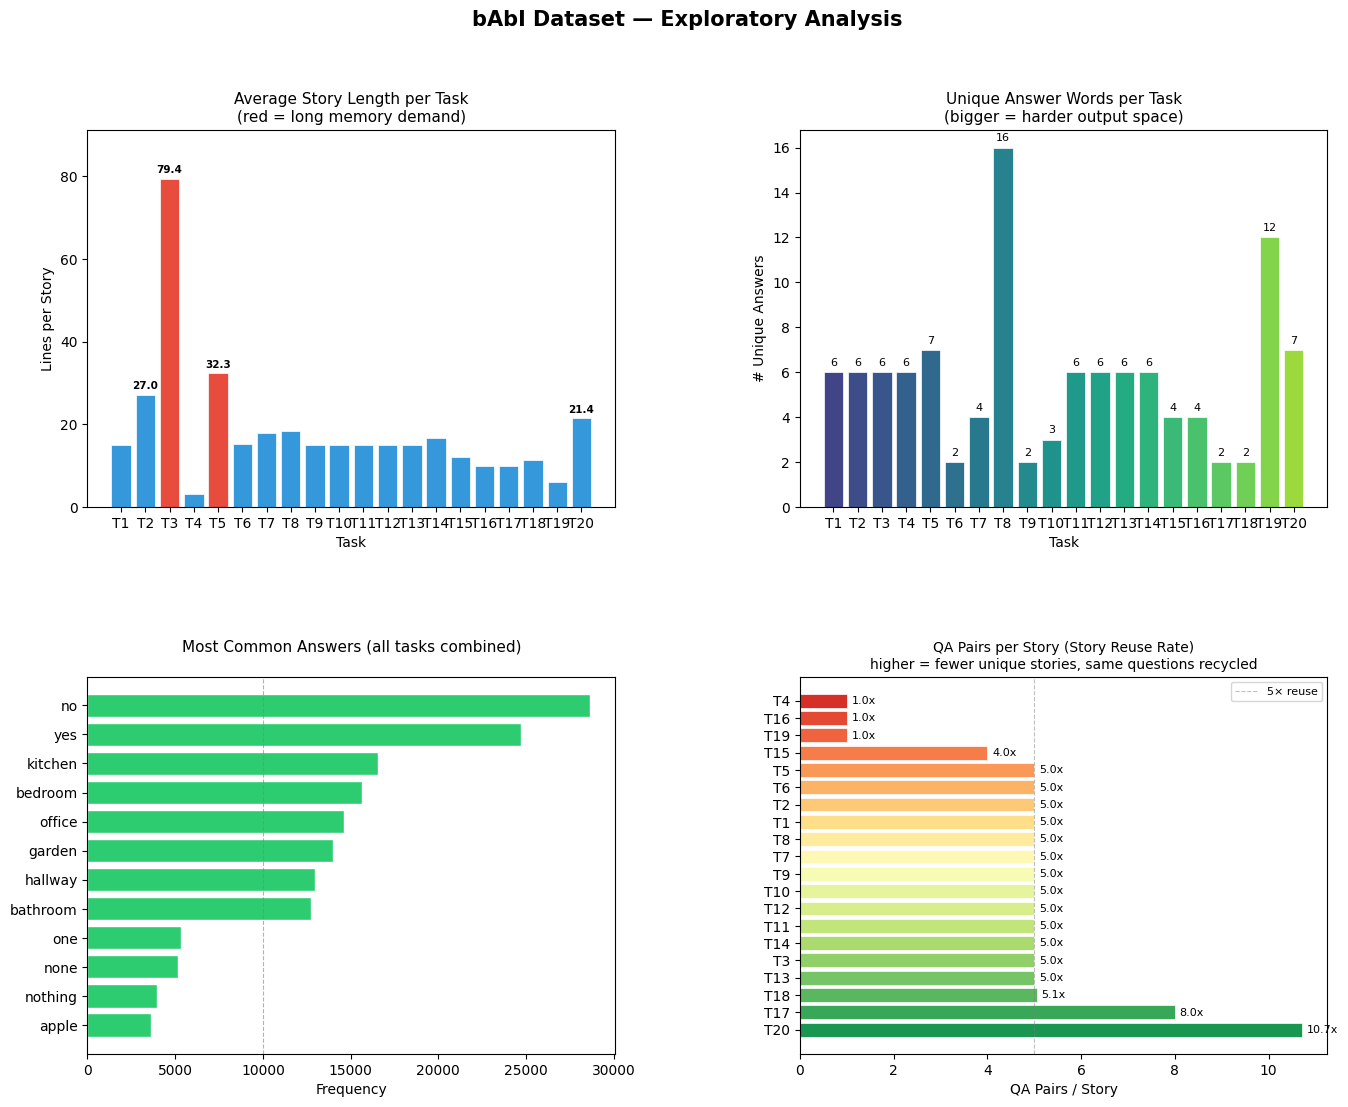

In [11]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('bAbI Dataset — Exploratory Analysis', fontsize=15, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

task_ids    = list(range(1, 21))
task_labels = ['T%d' % i for i in task_ids]
avg_lens    = [stats[i]['avg_story_len'] for i in task_ids]
unique_ans  = [stats[i]['unique_ans']    for i in task_ids]

# ── 1. Average story length per task ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
colors = ['#e74c3c' if l > 30 else '#3498db' for l in avg_lens]
bars = ax1.bar(task_labels, avg_lens, color=colors, edgecolor='white', linewidth=0.5)
ax1.set_title('Average Story Length per Task\n(red = long memory demand)', fontsize=11)
ax1.set_xlabel('Task'); ax1.set_ylabel('Lines per Story')
ax1.set_ylim(0, max(avg_lens) * 1.15)
for bar, v in zip(bars, avg_lens):
    if v > 20:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(v), ha='center', va='bottom', fontsize=7.5, fontweight='bold')

# ── 2. Answer vocabulary size per task ────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
palette = plt.cm.viridis(np.linspace(0.2, 0.85, len(task_ids)))
ax2.bar(task_labels, unique_ans, color=palette, edgecolor='white', linewidth=0.5)
ax2.set_title('Unique Answer Words per Task\n(bigger = harder output space)', fontsize=11)
ax2.set_xlabel('Task'); ax2.set_ylabel('# Unique Answers')
for i, v in enumerate(unique_ans):
    ax2.text(i, v + 0.2, str(v), ha='center', va='bottom', fontsize=8)

# ── 3. Global answer frequency (top 12) ───────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
all_answers = [a for s in stats.values() for a in s['answers']]
top_ans = Counter(all_answers).most_common(12)
words, cnts = zip(*top_ans)
ax3.barh(list(reversed(words)), list(reversed(cnts)), color='#2ecc71', edgecolor='white')
ax3.set_title('Most Common Answers (all tasks combined)\n', fontsize=11)
ax3.set_xlabel('Frequency')
ax3.axvline(x=10000, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

# ── 4. QA pairs per story (story reuse rate) ─────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
tr_stories = [stats[i]['tr_stories'] for i in task_ids]
tr_qa      = [stats[i]['tr_qa']      for i in task_ids]
qa_per_story = [q / s for q, s in zip(tr_qa, tr_stories)]

cmap_vals = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(task_ids)))
sorted_idx = np.argsort(qa_per_story)[::-1]
sorted_labels = [task_labels[i] for i in sorted_idx]
sorted_vals   = [qa_per_story[i] for i in sorted_idx]
sorted_colors = [cmap_vals[rank] for rank, _ in enumerate(sorted_idx)]

h_bars = ax4.barh(sorted_labels, sorted_vals, color=sorted_colors, edgecolor='white', linewidth=0.5)
ax4.set_title('QA Pairs per Story (Story Reuse Rate)\nhigher = fewer unique stories, same questions recycled', fontsize=10)
ax4.set_xlabel('QA Pairs / Story')
ax4.axvline(x=5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='5× reuse')
ax4.legend(fontsize=8)
for bar, v in zip(h_bars, sorted_vals):
    ax4.text(v + 0.1, bar.get_y() + bar.get_height()/2,
             '%.1fx' % v, va='center', fontsize=8)

plt.savefig('../images/babi_analysis.png', dpi=130, bbox_inches='tight')
plt.show()
print("Figure saved to babi_analysis.png")


### What the data is telling us

First thing that jumps out the vocabulary is only ~145 words. That's not a typo. This dataset was never meant to test whether a model understands language; it's testing whether it can reason over it. The words are simple. The logic isn't.

Story length is probably the most honest measure of difficulty here. Most tasks sit around 15 lines, which is manageable. Task 3 though? Average of 79 lines per story. The model has to read through all of that, figure out which three sentences actually matter, and ignore the rest. That's where a lot of memory architectures quietly fall apart.

Something that's easy to miss: every task has exactly 10k QA pairs, but the number of actual stories behind them is all over the place. Task 20 only has 933 unique stories so those same stories are being asked about roughly 10 different times each. A model that just memorizes the templates will look fine on paper but hasn't really learned anything.

On the answer side, tasks 6, 9, 17, and 18 only have two possible answers. Yes/no, left/right. Random guessing already gets you 50% there, so high accuracy on those doesn't say much. Task 8 is the opposite, it has 16 unique answers and that's where you'd actually expect a weaker model to struggle.

The location words (kitchen, bedroom, office, garden) absolutely dominate the answer distribution across all tasks combined. Makes sense given how many tasks are about tracking where people go, but it's worth knowing in case you're looking at aggregate stats and wondering why the model seems biased toward place names.

---
## 3. Preprocessing

- Parse stories: returns story, query and answer
- Build vocab: retrieve the vocabulary V
- Vectorize with Bag of Words: create a vector giving the position of each word of the sentence in the vocabulary. Instead of generate one hot vector of size |V| for each word of the sentence, we directly retrieve the position of the word in the vocabulary.

In [12]:
# ============================================================
# Step 3 : Preprocessing — text → PyTorch Tensors
# ============================================================

def parse_stories(path):
    """
    Reads a bAbI file and returns a list of (story, question, answer).
    
    Example of a bAbI line:
    “1 Mary went to the kitchen.”      → story sentence
    “2 Where is Mary?\toffice\t1”      → question \t answer \t context
    """
    data, story = [], []
    with open(path) as f:
        for line in f:
            line = line.strip().lower()
            idx, line = line.split(' ', 1)
            idx = int(idx)
            if idx == 1:
                story = [] 
            if '\t' in line:
                q, a, _ = line.split('\t')
                data.append((list(story), q, a))
            else:
                story.append(line.rstrip('.'))
    return data


def build_vocab(datasets):
    """Builds vocabulary using all the words covered."""
    vocab = set()
    for data in datasets:
        for story, q, a in data:
            for sent in story:
                vocab.update(sent.split())
            vocab.update(q.split())
            vocab.add(a)
    # index 0 = padding, start at 1
    word2idx = {w: i+1 for i, w in enumerate(sorted(vocab))}
    word2idx['<pad>'] = 0
    return word2idx

def vectorize(data, word2idx, memory_size=50, sentence_size=11):
    """
    Converts stories into numerical tensors.

    1. Encode each sentence
        "mary went to the kitchen" → [5, 8, 7, 6, 4, 0, 0, ...] (sentence_size)
        "where is mary"            → [9, 2, 5, 0, 0, 0, 0, ...]
        "kitchen"                  → 4
    2. Build tensors of shape (N, memory_size, sentence_size) for stories,
       (N, sentence_size) for queries, and (N,) for answers.
    where N is the number of QA pairs, memory_size is the max number of sentences to keep in the story, 
    and sentence_size is the max number of words per sentence.
    Stories longer than memory_size will be truncated (keep the most recent sentences).

    Returns stories, queries, and answers — all as PyTorch tensors.
    """
    stories, queries, answers = [], [], []
    
    for story, q, a in data:
        # Encode each sentence → a list of indices, padded to sentence_size
        def encode_sent(sent):
            words = sent.split()[:sentence_size]
            indices = [word2idx.get(w, 0) for w in words]
            # right padding
            indices += [0] * (sentence_size - len(indices))
            return indices
        
        # Take the last memory_size sentences, padded if needed
        encoded_story = [encode_sent(s) for s in story[-memory_size:]]
        # Fill out the story with some filler sentences if it's too short
        while len(encoded_story) < memory_size:
            encoded_story.insert(0, [0] * sentence_size)
        
        stories.append(encoded_story)
        queries.append(encode_sent(q))
        answers.append(word2idx.get(a, 0))
    
    return (
        torch.tensor(stories,  dtype=torch.long),   # (N, memory_size, sent_size)
        torch.tensor(queries,  dtype=torch.long),   # (N, sent_size)
        torch.tensor(answers,  dtype=torch.long),   # (N,)
    )


In [13]:
# --- Example task 1 ---
TASK_ID = 1
train_file = os.path.join(data_dir, f'qa{TASK_ID}_single-supporting-fact_train.txt')
test_file  = os.path.join(data_dir, f'qa{TASK_ID}_single-supporting-fact_test.txt')

train_data = parse_stories(train_file)
test_data  = parse_stories(test_file)

word2idx   = build_vocab([train_data, test_data])
VOCAB_SIZE = len(word2idx)
print(f"Vocabulaire : {VOCAB_SIZE} mots")

train_stories, train_queries, train_answers = vectorize(train_data, word2idx)
test_stories,  test_queries,  test_answers  = vectorize(test_data,  word2idx)
print(f"Train : {train_stories.shape}, Test : {test_stories.shape}")

Vocabulaire : 24 mots
Train : torch.Size([10000, 50, 11]), Test : torch.Size([1000, 50, 11])


---
## 4. Model MemN2N


In [ ]:
# ============================================================
# Step 4 : MemN2N
# ============================================================

def position_encoding(sentence_size, embedding_dim):
    """
    Position Encoding (PE) of Section 4.1 : encode the order of words.
    Returns the position encoding matrix of shape (embedding_dim, sentence_size) by computing each element lkj as described in the article.
    """
    J, d = sentence_size, embedding_dim # J = number of words in the sentence, d = embedding dimension
    encoding = torch.ones(d, J)
    for k in range(1, d + 1):       # k dimension of the embedding
        for j in range(1, J + 1):   # j position of the word in the sentence
            encoding[k-1, j-1] = (1 - j/(J+1)) - (k/(d+1)) * (1 - 2*j/(J+1))
    return encoding  # (d, J)

class MemN2N(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_hops,
                 memory_size, sentence_size):
        super().__init__()
        self.num_hops      = num_hops
        self.embedding_dim = embedding_dim

        # --- Model parameters declaration ---
        # K hops require K+1 embeddings for the ADJACENT (not layer-wise) scheme:
        # A^k = embeddings[k],  C^k = embeddings[k+1]
        # A^k+1 = embeddings[k+1] = C^k
        # B   = embeddings[0] = A^1
        # W^T = embeddings[K] = C^K
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
            for _ in range(num_hops + 1)
        ])

        # Temporal encoding learned during training(Section 4.1) - encode temporal information
        self.temporal_A = nn.Embedding(memory_size, embedding_dim) # TA
        self.temporal_C = nn.Embedding(memory_size, embedding_dim) # TC

        # Position encoding fixed (not learned)
        pe = position_encoding(sentence_size, embedding_dim) # mi = sum_j lj * Axij
        self.register_buffer('pe', pe)  # saved, not trained

        # Weight initialization by gaussian distribution mu = 0, σ=0.1 (Section 4.2)
        for emb in self.embeddings:
            nn.init.normal_(emb.weight, mean=0, std=0.1)

    def encode(self, sequences, embedding, temporal):
        """
        
        sequences : (batch, memory_size, sentence_size)
        Returns  : (batch, memory_size, embed_dim)
        """
        x = embedding(sequences)           # Embedded each word for each sentence (B, M, J, d) - Axij
        x = (x * self.pe.T).sum(dim=2)     # position encoding sum over words (B, M, d) - mi = Σj lj · Axij
        
        # temporal encoding - mi = Σj lj · Axij + TA(i)
        M = sequences.size(1)
        t = torch.arange(M, device=x.device)
        # temporal(t) retrieve the i-th line of the temporal embedding matrix t
        x = x + temporal(t).unsqueeze(0)   # (B, M, d)
        return x

    def forward(self, stories, queries):
        """
        stories : (batch, memory_size, sentence_size)
        queries : (batch, sentence_size)
        Returns logits : (batch, vocab_size)
        """
        # Encode the query with B = embeddings[0] - u^1 = Σj lj · Bqj
        q = self.embeddings[0](queries)    # (B, J, d)
        q = q * self.pe[:, :queries.size(1)].T
        u = q.sum(dim=1)                   # u^1 : (B, d)

        for hop in range(self.num_hops):
            # Encode memory with A^k et C^k
            m = self.encode(stories, self.embeddings[hop],     self.temporal_A) # Input memory representation
            c = self.encode(stories, self.embeddings[hop + 1], self.temporal_C) # Output memory representation

            # Attention: p = softmax(u^T m)  — equation (1)
            scores = torch.bmm(m, u.unsqueeze(2)).squeeze(2)  # (B, M)
            p      = F.softmax(scores, dim=1)                  # (B, M)

            # Output vector: o = sum(p_i * c_i)  — equation (2)
            o = torch.bmm(p.unsqueeze(1), c).squeeze(1)       # (B, d)

            # u^{k+1} = u^k + o^k  — equation (4)
            u = u + o

        # Generating the final prediction: W^T = embeddings[K].weight
        W = self.embeddings[self.num_hops].weight              # (V, d)
        logits = torch.matmul(u, W.T)                          # (B, V)
        return logits

---
## 5. Training and Evaluation

In [ ]:
# ============================================================
# Step 5 : Training - For one task (task 1)
# ============================================================

# No momentum, no weight decay, no dropout
EMBEDDING_DIM = 20    # d=20 for training each task (Section 4.2)
NUM_HOPS      = 3
MEMORY_SIZE   = 50
SENTENCE_SIZE = 11
BATCH_SIZE    = 32
EPOCHS        = 100
LR            = 0.01 # Learning rate (divided by 2 every 25 epochs, Section 4.2)

model     = MemN2N(VOCAB_SIZE, EMBEDDING_DIM, NUM_HOPS,
                   MEMORY_SIZE, SENTENCE_SIZE).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR)

# DataLoader pour batcher automatiquement
from torch.utils.data import TensorDataset, DataLoader

train_set    = TensorDataset(train_stories, train_queries, train_answers)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)

train_losses = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0

    for s, q, a in train_loader:
        s, q, a = s.to(DEVICE), q.to(DEVICE), a.to(DEVICE)
        optimizer.zero_grad()
        logits = model(s, q)
        loss   = criterion(logits, a)
        loss.backward()
        # Gradient clipping norm L2 max=40 (Section 4.2)
        nn.utils.clip_grad_norm_(model.parameters(), 40)
        optimizer.step()
        total_loss += loss.item()

    train_losses.append(total_loss / len(train_loader))

    # Learning rate annealing : ÷2 each 25 epochs (Section 4.2)
    if epoch % 25 == 0:
        for g in optimizer.param_groups:
            g['lr'] /= 2
        print(f"Epoch {epoch:3d} | Loss: {train_losses[-1]:.4f} | LR → {g['lr']:.5f}")

# ============================================================
# Evaluation - for one task
# ============================================================

def evaluate(model, stories, queries, answers, batch_size=256):
    model.eval()
    correct = 0
    loader  = DataLoader(TensorDataset(stories, queries, answers),
                         batch_size=batch_size)
    with torch.no_grad():
        for s, q, a in loader:
            s, q, a  = s.to(DEVICE), q.to(DEVICE), a.to(DEVICE)
            logits   = model(s, q)
            preds    = logits.argmax(dim=1)
            correct += (preds == a).sum().item()
    return correct / len(answers)

acc = evaluate(model, test_stories, test_queries, test_answers)
print(f"\nTest accuracy task {TASK_ID}: {acc*100:.1f}%")

Epoch  25 | Loss: 1.7967 | LR → 0.00500
Epoch  50 | Loss: 1.7936 | LR → 0.00250
Epoch  75 | Loss: 1.7925 | LR → 0.00125
Epoch 100 | Loss: 1.7919 | LR → 0.00063

Test accuracy task 1: 20.0%


In [16]:
# ============================================================
# Evaluation over all the 20 tasks — to compare with Table 1
# ============================================================

TASK_FILES = {
    1:  'single-supporting-fact',
    2:  'two-supporting-facts',
    3:  'three-supporting-facts',
    4:  'two-arg-relations',
    5:  'three-arg-relations',
    6:  'yes-no-questions',
    7:  'counting',
    8:  'lists-sets',
    9:  'simple-negation',
    10: 'indefinite-knowledge',
    11: 'basic-coreference',
    12: 'conjunction',
    13: 'compound-coreference',
    14: 'time-reasoning',
    15: 'basic-deduction',
    16: 'basic-induction',
    17: 'positional-reasoning',
    18: 'size-reasoning',
    19: 'path-finding',
    20: 'agents-motivations'
}

def train_and_evaluate_task(task_id, data_dir, epochs=100, 
                             embedding_dim=20, num_hops=3,
                             memory_size=50, sentence_size=11,
                             batch_size=32, lr=0.01):
    """
    Entraîne et évalue MemN2N sur une tâche bAbI.
    Retourne le taux d'erreur (%) pour correspondre à la Table 1.
    """
    # --- data loading ---
    task_name  = TASK_FILES[task_id]
    train_file = os.path.join(data_dir, f'qa{task_id}_{task_name}_train.txt')
    test_file  = os.path.join(data_dir, f'qa{task_id}_{task_name}_test.txt')

    train_data = parse_stories(train_file)
    test_data  = parse_stories(test_file)
    word2idx   = build_vocab([train_data, test_data])
    vocab_size = len(word2idx)

    train_s, train_q, train_a = vectorize(train_data, word2idx,
                                           memory_size, sentence_size)
    test_s,  test_q,  test_a  = vectorize(test_data,  word2idx,
                                           memory_size, sentence_size)

    # --- Model ---
    model     = MemN2N(vocab_size, embedding_dim, num_hops,
                       memory_size, sentence_size).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    loader = DataLoader(TensorDataset(train_s, train_q, train_a),
                        batch_size=batch_size, shuffle=True)

    # --- Training ---
    for epoch in range(1, epochs + 1):
        model.train()
        for s, q, a in loader:
            s, q, a = s.to(DEVICE), q.to(DEVICE), a.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(s, q), a)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 40)
            optimizer.step()

        # Learning rate annealing ÷2 at each 25 epochs
        if epoch % 25 == 0:
            for g in optimizer.param_groups:
                g['lr'] /= 2

    # --- Evaluation ---
    model.eval()
    correct = 0
    with torch.no_grad():
        for s, q, a in DataLoader(TensorDataset(test_s, test_q, test_a),
                                   batch_size=256):
            s, q, a = s.to(DEVICE), q.to(DEVICE), a.to(DEVICE)
            preds    = model(s, q).argmax(dim=1)
            correct += (preds == a).sum().item()

    error_rate = (1 - correct / len(test_a)) * 100
    return round(error_rate, 1)


# ============================================================
# Launch evaluation on 20 tasks and compare to the article outcomes
# ============================================================

# Outcomes of the Table 1 (MemN2N PE+LS, 3 hops, joint, 1k)
# For reference — column "PE LS joint" of the paper
PAPER_RESULTS = {
    1: 0.1,  2: 14.0, 3: 33.1, 4: 5.7,  5: 14.8,
    6: 3.3,  7: 17.9, 8: 10.1, 9: 3.1,  10: 6.6,
    11: 0.9, 12: 0.3, 13: 1.4, 14: 8.2, 15: 0.0,
    16: 3.5, 17: 44.5,18: 9.2, 19: 90.2,20: 0.0
}

print("Training on the 20 tasks...")
print(f"{'Task':<6} {'Name':<30} {'Our error':>12} {'Article':>8} {'Diff':>6}")
print("-" * 65)

results = {}
for task_id in range(1, 21):
    err = train_and_evaluate_task(task_id, data_dir)
    results[task_id] = err
    paper = PAPER_RESULTS[task_id]
    diff  = err - paper
    flag  = " ⚠️" if err > paper + 10 else ""
    print(f"  {task_id:<4} {TASK_FILES[task_id]:<30} {err:>11.1f}% "
          f"{paper:>7.1f}% {diff:>+6.1f}{flag}")

mean_ours  = sum(results.values()) / 20
mean_paper = sum(PAPER_RESULTS.values()) / 20
failed_ours  = sum(1 for e in results.values() if e > 5)
failed_paper = sum(1 for e in PAPER_RESULTS.values() if e > 5)

print("-" * 65)
print(f"  {'Mean error':<34} {mean_ours:>11.1f}% {mean_paper:>7.1f}%")
print(f"  {'Failed tasks (err > 5%)':<34} {failed_ours:>11}  {failed_paper:>7}")

Entraînement sur les 20 tâches...
Task   Name                           Notre erreur  Article   Diff
-----------------------------------------------------------------
  1    single-supporting-fact                81.3%     0.1%  +81.2 ⚠️
  2    two-supporting-facts                  81.1%    14.0%  +67.1 ⚠️


KeyboardInterrupt: 